In [441]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import silhouette_score

In [442]:
df = pd.read_csv("C:\\Users\\Tony\\Documents\\GitHub\\EAE-598-Project\\final_all_events.csv")
df.head()

,time,level,pv_300,pv_700,pv_850,pv_925,pv_1000,wnd_300,wnd_500,wnd_850,...,thetae_grad_850,thetae_grad_925,thetae_grad_1000,t_grad_850,t_grad_925,t_grad_1000,label,year,month,day
0,2017-02-20 03:00:00,300.0,1.615085e-12,5.168937e-13,1.192982e-12,8.204532e-13,3.146415e-13,66.406730,46.775124,14.784239,...,12.238490,9.950269,7.297508,5.513050,3.916206,2.792917,MFW,2017,2,20
1,2019-02-13 17:00:00,300.0,2.824925e-12,6.330504e-13,7.191460e-13,2.770781e-13,1.959496e-13,62.199850,33.380860,4.886407,...,9.568939,9.987158,5.880394,3.667785,3.668505,1.591186,MFW,2019,2,13
2,2015-11-19 02:00:00,300.0,-3.753535e-14,5.650719e-13,7.535887e-13,1.251950e-12,1.095274e-13,46.878395,32.892265,23.937796,...,4.126061,4.966980,6.084853,1.439914,1.810055,2.012980,MFW,2015,11,19
3,2016-01-28 17:00:00,300.0,1.088309e-13,8.542314e-13,2.183340e-12,1.469326e-12,4.105159e-13,62.548008,47.574287,23.934720,...,5.187433,5.209870,2.882797,3.458344,1.929978,0.705986,MFW,2016,1,28
4,2014-02-07 13:00:00,300.0,3.312839e-13,5.557943e-13,8.091834e-13,2.026526e-12,7.450257e-13,43.977250,34.692270,24.003717,...,6.107335,8.828790,3.782991,0.839231,2.512393,1.679689,MFW,2014,2,7


In [443]:
df['vort_def'] =  df['rel_vort_1000'] / df['total_deformation_1000']
df['low_level_pv'] = (df['pv_925'] + df['pv_850']) / 2

In [444]:
df.columns

Index(['time', 'level', 'pv_300', 'pv_700', 'pv_850', 'pv_925', 'pv_1000',
       'wnd_300', 'wnd_500', 'wnd_850', 'z_250', 'z_500', 'z_850', 'z_925',
       'z_1000', 't_250', 't_500', 't_850', 't_925', 't_1000', 'q_850',
       'q_925', 'q_1000', 'ivt', 'ivt_grad', 'thickness_1000_500', 'qvec_div',
       'qvec_magn', 'abs_vort', 'thetae_850', 'thetae_925', 'thetae_1000',
       'fgen_700', 'fgen_850', 'fgen_925', 'fgen_1000', 'tadv_500', 'tadv_850',
       'tadv_925', 'tadv_1000', 'rel_vort_500', 'rel_vort_850', 'rel_vort_925',
       'rel_vort_1000', 'total_deformation_500', 'total_deformation_850',
       'total_deformation_925', 'total_deformation_1000',
       'shearing_deformation_500', 'shearing_deformation_850',
       'shearing_deformation_925', 'shearing_deformation_1000',
       'stretching_deformation_500', 'stretching_deformation_850',
       'stretching_deformation_925', 'stretching_deformation_1000',
       'thetae_grad_850', 'thetae_grad_925', 'thetae_grad_1000', 't_g

In [445]:
drop_cols = ['time', 'level', 'label', 'year', 'month', 'day']
feature_cols = [col for col in df.columns if col not in drop_cols]

In [446]:
# Random seed
zid = 1895595

basic_features = df[feature_cols]

Determine the number of clusters using the Elbow Method and Silhouette Method

C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows wi

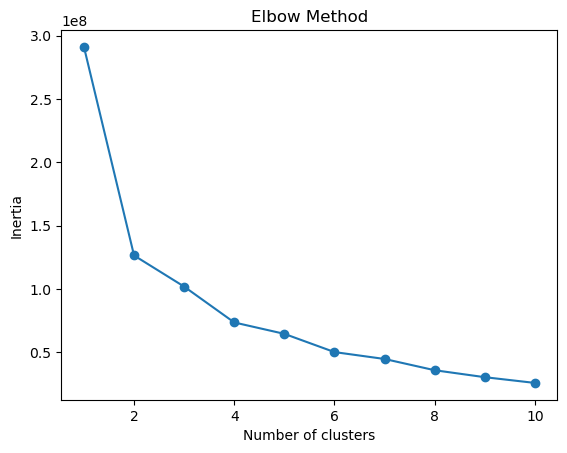

In [447]:
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=zid, n_init='auto')
    kmeans.fit(basic_features)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows wi

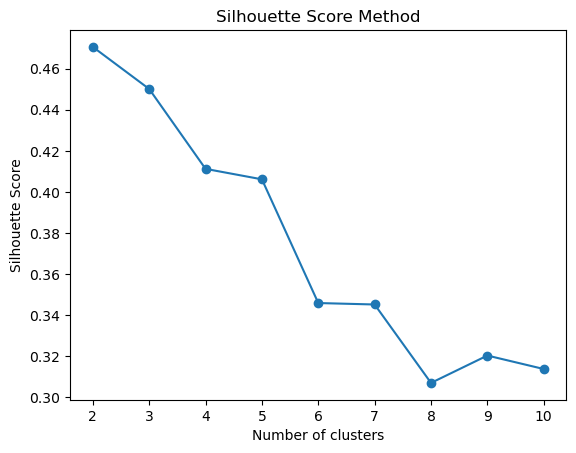

In [448]:
silhouette_scores = []
for i in range(2, 11): 
    kmeans = KMeans(n_clusters=i, random_state=zid, n_init='auto')
    kmeans.fit(basic_features)
    score = silhouette_score(basic_features, kmeans.labels_)
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score Method')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [449]:
kmeans = KMeans(n_clusters=4, random_state=zid).fit(basic_features.values)

df['cluster'] = kmeans.labels_
df['cluster']

C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


0     0
1     0
2     1
3     0
4     0
5     1
6     1
7     0
8     0
9     1
10    0
11    3
12    0
13    0
14    1
15    1
16    1
17    1
18    1
19    1
20    0
21    0
22    3
23    0
24    1
25    0
26    1
27    3
28    1
29    0
30    0
31    2
32    3
33    1
34    0
35    1
36    0
37    1
38    1
39    1
40    0
41    0
42    0
43    0
44    0
45    1
46    1
47    3
48    1
49    1
Name: cluster, dtype: int32

Let's see how the k-means clustering did compared to the labels

In [450]:
pd.crosstab(df['cluster'], df['label'])

label,MFW,noMFW
cluster,,
0,9,13
1,12,10
2,1,0
3,3,2


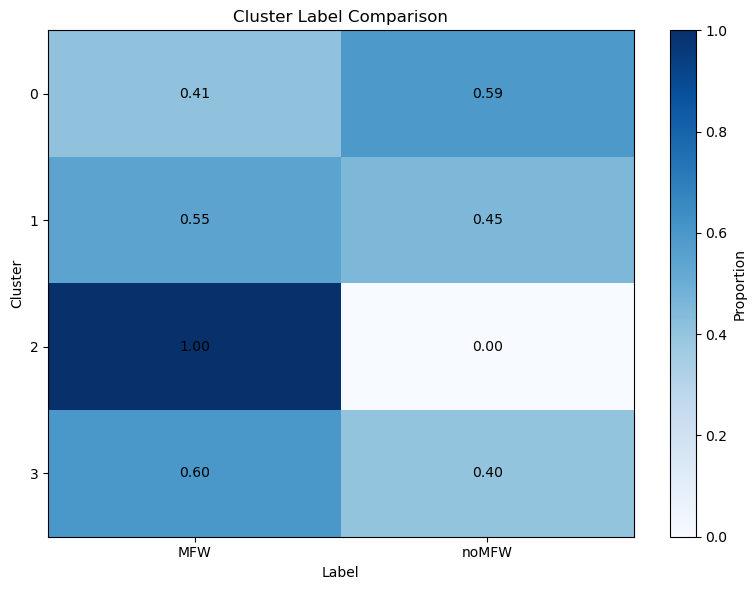

In [451]:
label_cluster_table = pd.crosstab(df['cluster'], df['label'])

label_cluster_table_normalized = label_cluster_table.div(label_cluster_table.sum(axis=1), axis=0)

plt.figure(figsize=(8, 6))
plt.imshow(label_cluster_table_normalized, cmap="Blues", aspect="auto")
plt.colorbar(label="Proportion")
plt.xticks(ticks=np.arange(label_cluster_table.columns.size), labels=label_cluster_table.columns, rotation=0)
plt.yticks(ticks=np.arange(label_cluster_table.index.size), labels=label_cluster_table.index)
plt.title("Cluster Label Comparison")
plt.xlabel("Label")
plt.ylabel("Cluster")

for i in range(label_cluster_table_normalized.shape[0]):
    for j in range(label_cluster_table_normalized.shape[1]):
        plt.text(j, i, f"{label_cluster_table_normalized.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

Not good - so let's try scaling the features!

In [452]:
scaler = StandardScaler()
basic_features_scaled = scaler.fit_transform(basic_features.values)

C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows wi

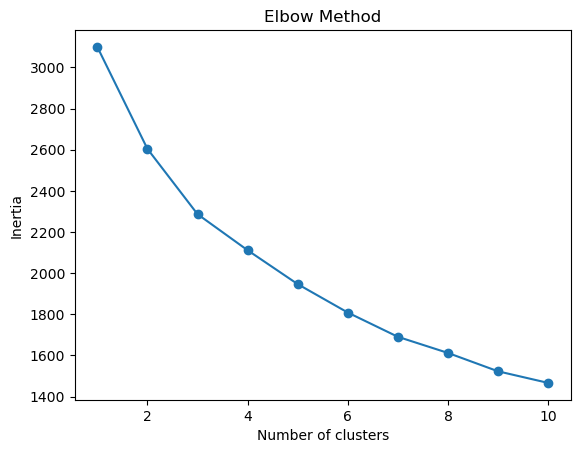

In [453]:
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=zid, n_init='auto')
    kmeans.fit(basic_features_scaled)
    inertia.append(kmeans.inertia_)
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows wi

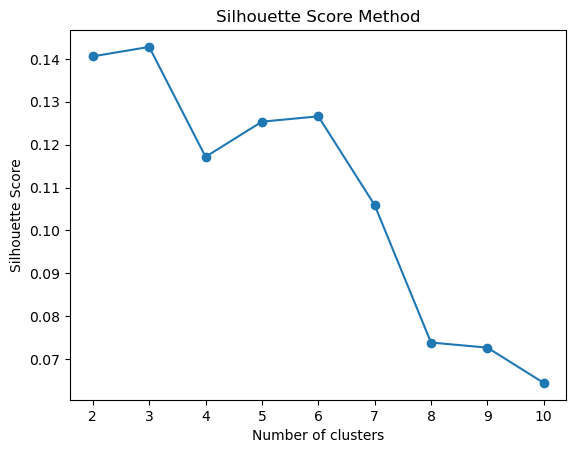

In [454]:
silhouette_scores = []
for i in range(2, 11): 
    kmeans = KMeans(n_clusters=i, random_state=zid, n_init='auto')
    kmeans.fit(basic_features_scaled)
    score = silhouette_score(basic_features_scaled, kmeans.labels_)
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score Method')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [455]:
kmeans_scaled = KMeans(n_clusters=4, random_state=zid).fit(basic_features_scaled)

df['cluster_scaled'] = kmeans_scaled.labels_
df['cluster_scaled']

C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


0     0
1     0
2     3
3     0
4     0
5     1
6     1
7     1
8     0
9     3
10    0
11    3
12    0
13    0
14    3
15    0
16    2
17    3
18    1
19    3
20    0
21    3
22    3
23    0
24    1
25    0
26    3
27    3
28    3
29    2
30    2
31    0
32    0
33    3
34    3
35    1
36    3
37    3
38    2
39    0
40    0
41    0
42    0
43    2
44    0
45    3
46    1
47    3
48    3
49    3
Name: cluster_scaled, dtype: int32

In [456]:
pd.crosstab(df['cluster_scaled'], df['label'])

label,MFW,noMFW
cluster_scaled,,
0,9,10
1,5,2
2,1,4
3,10,9


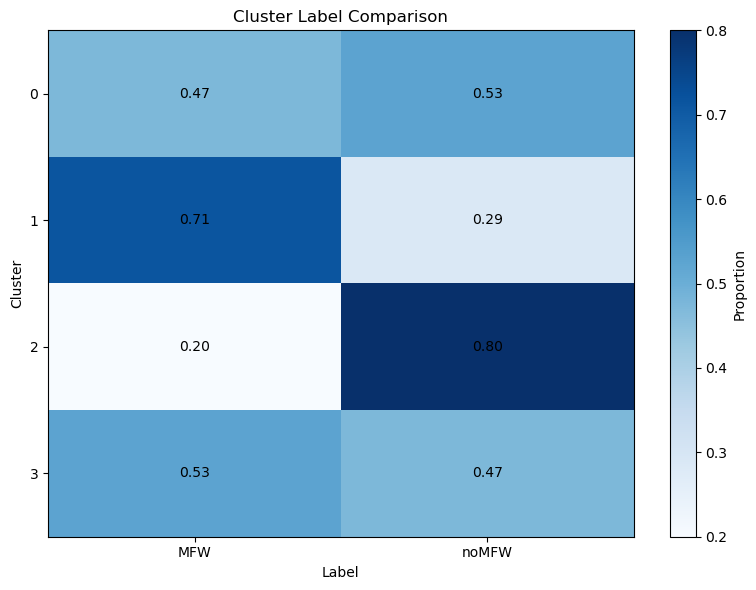

In [457]:
label_cluster_table = pd.crosstab(df['cluster_scaled'], df['label'])

label_cluster_table_normalized = label_cluster_table.div(label_cluster_table.sum(axis=1), axis=0)

plt.figure(figsize=(8, 6))
plt.imshow(label_cluster_table_normalized, cmap="Blues", aspect="auto")

plt.colorbar(label="Proportion")
plt.xticks(ticks=np.arange(label_cluster_table.columns.size), labels=label_cluster_table.columns, rotation=0)
plt.yticks(ticks=np.arange(label_cluster_table.index.size), labels=label_cluster_table.index)
plt.title("Cluster Label Comparison")
plt.xlabel("Label")
plt.ylabel("Cluster")

for i in range(label_cluster_table_normalized.shape[0]):
    for j in range(label_cluster_table_normalized.shape[1]):
        plt.text(j, i, f"{label_cluster_table_normalized.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

In [458]:
mi = mutual_info_classif(basic_features_scaled, df['label'], discrete_features=False)
mi_series = pd.Series(mi, index=feature_cols).sort_values(ascending=False)

top_features = mi_series.head(10).index.tolist()
top_features_selected = basic_features_scaled[:, [feature_cols.index(f) for f in top_features]]
kmeans = KMeans(n_clusters=4, random_state=zid).fit(top_features_selected)

df['cluster_selected'] = kmeans.labels_
df['cluster_selected']

C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


0     3
1     1
2     0
3     3
4     1
5     0
6     0
7     0
8     0
9     3
10    0
11    0
12    0
13    0
14    1
15    0
16    1
17    0
18    1
19    0
20    1
21    1
22    0
23    3
24    3
25    1
26    0
27    0
28    3
29    2
30    1
31    0
32    0
33    0
34    0
35    3
36    3
37    0
38    2
39    0
40    1
41    1
42    1
43    2
44    1
45    3
46    3
47    3
48    3
49    0
Name: cluster_selected, dtype: int32

In [459]:
pd.crosstab(df['cluster_selected'], df['label'])

label,MFW,noMFW
cluster_selected,,
0,12,10
1,3,10
2,1,2
3,9,3


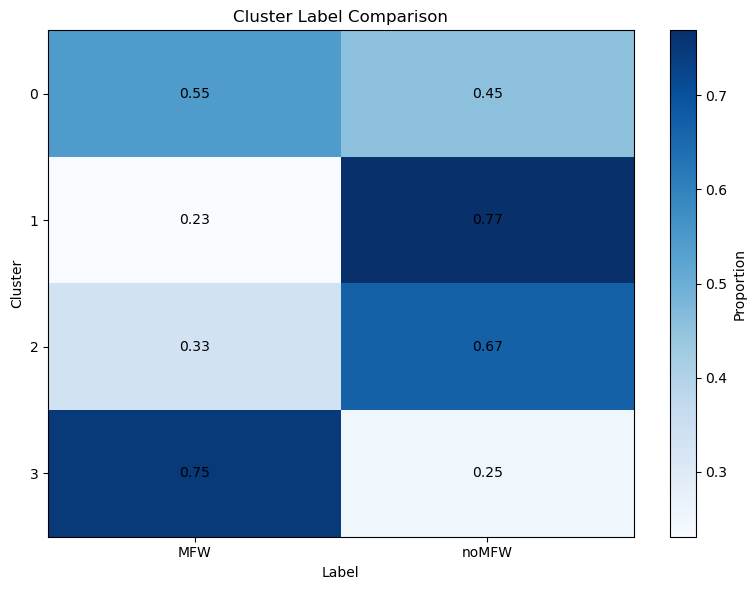

In [460]:
label_cluster_table = pd.crosstab(df['cluster_selected'], df['label'])
label_cluster_table_normalized = label_cluster_table.div(label_cluster_table.sum(axis=1), axis=0)

plt.figure(figsize=(8, 6))
plt.imshow(label_cluster_table_normalized, cmap="Blues", aspect="auto")

plt.colorbar(label="Proportion")
plt.xticks(ticks=np.arange(label_cluster_table.columns.size), labels=label_cluster_table.columns, rotation=0)
plt.yticks(ticks=np.arange(label_cluster_table.index.size), labels=label_cluster_table.index)
plt.title("Cluster Label Comparison")
plt.xlabel("Label")
plt.ylabel("Cluster")

for i in range(label_cluster_table_normalized.shape[0]):
    for j in range(label_cluster_table_normalized.shape[1]):
        plt.text(j, i, f"{label_cluster_table_normalized.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

In [461]:
global_mean = pd.DataFrame(top_features_selected, columns=top_features).mean()
cluster_profiles = pd.DataFrame(top_features_selected, columns=top_features).groupby(df['cluster_selected']).mean()
cluster_diffs = cluster_profiles - global_mean

cluster_diffs

,stretching_deformation_1000,shearing_deformation_925,fgen_700,tadv_925,wnd_300,wnd_500,qvec_div,total_deformation_925,fgen_925,rel_vort_850
cluster_selected,,,,,,,,,,
0,0.328165,-0.349993,0.150449,0.208850,-0.683883,-0.797345,-0.242684,-0.342700,-0.280891,-0.433536
1,-0.695339,0.383816,0.310664,-0.538180,0.653869,0.487886,0.596221,0.061087,-0.132234,0.049692
2,-0.775886,2.723655,-0.243012,-1.497411,0.083054,0.393581,1.988153,2.578873,2.932860,2.080205
3,0.345619,-0.455061,-0.551623,0.574490,0.524664,0.834860,-0.698024,-0.082612,-0.074995,0.220933


In [462]:
label_cluster_table_normalized

label,MFW,noMFW
cluster_selected,,
0,0.545455,0.454545
1,0.230769,0.769231
2,0.333333,0.666667
3,0.750000,0.250000


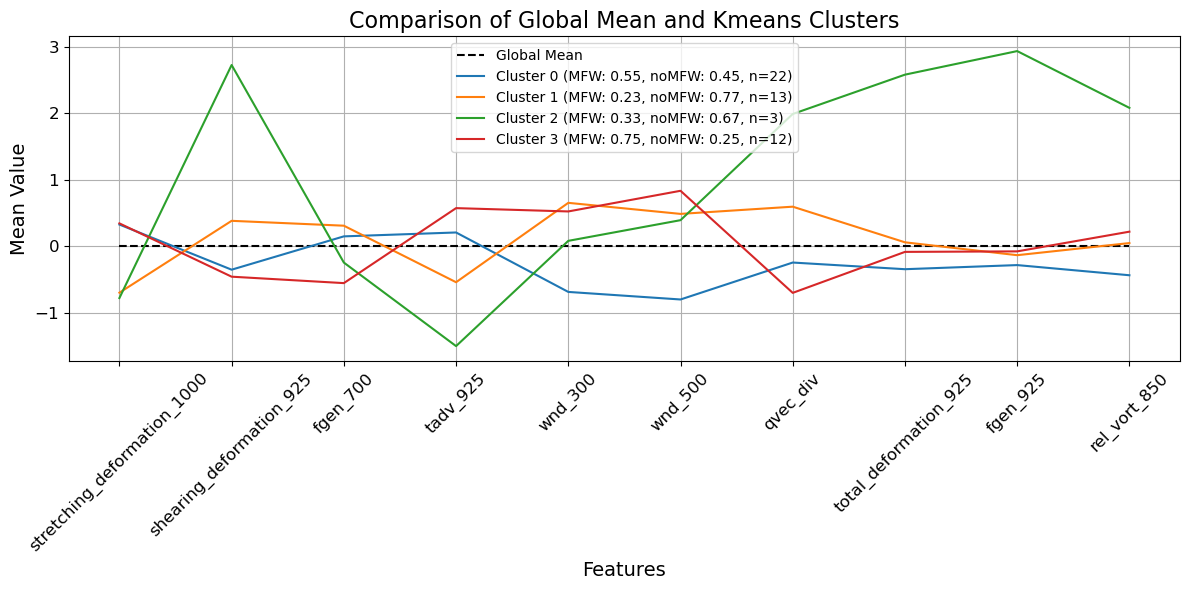

In [ ]:
cluster_sizes = df['cluster_selected'].value_counts()

proportions = {cluster: f"MFW: {row['MFW']:.2f}, noMFW: {row['noMFW']:.2f}" for cluster, row in label_cluster_table_normalized.iterrows()}

selected_features = cluster_profiles.columns.tolist()
plt.figure(figsize=(12, 6))

global_mean.plot(label='Global Mean', linestyle='--', color='black')

for cluster in range(len(cluster_profiles)):
    cluster_label = f"Cluster {cluster} ({proportions[cluster]}, n={cluster_sizes[cluster]})"
    cluster_profiles.loc[cluster].plot(label=cluster_label)

plt.title('Comparison of Global Mean and Kmeans Clusters', fontsize=16)
plt.xlabel('Features', fontsize=14)
plt.ylabel('Mean Value', fontsize=14)
plt.xticks(ticks=range(len(selected_features)), labels=selected_features, rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper center')
plt.grid()
plt.tight_layout()
plt.show()

Let's use some of the variables the random forest thought were best!

In [464]:
best_vars_df = pd.read_csv("C:\\Users\\Tony\\Desktop\\top_50_variable_triplets.csv")
best_vars_df[0:15] # print the first 15 rows

,Var1,Var2,Var3,Precision,Recall,Accuracy
0,t_850,ivt,t_grad_850,1.000,1.0,1.0
1,pv_1000,ivt,tadv_925,1.000,1.0,1.0
2,pv_700,ivt,tadv_925,1.000,1.0,1.0
3,pv_300,ivt,tadv_925,1.000,1.0,1.0
4,pv_850,ivt,tadv_925,1.000,1.0,1.0
5,pv_925,ivt,tadv_925,1.000,1.0,1.0
6,q_850,ivt,t_grad_850,1.000,1.0,1.0
7,ivt,tadv_925,shearing_deformation_925,0.925,0.9,0.9
8,t_850,total_deformation_850,shearing_deformation_925,0.925,0.9,0.9
9,z_250,total_deformation_850,shearing_deformation_925,0.925,0.9,0.9


Let's count the number of instances the variables were found in the top 15-25

In [465]:
var_counts = best_vars_df.value_counts()
var_counts

Var1                   Var2                       Var3                        Precision  Recall  Accuracy
ivt                    shearing_deformation_1000  thetae_grad_850             0.925      0.9     0.9         1
wnd_300                fgen_925                   shearing_deformation_925    0.925      0.9     0.9         1
q_850                  ivt                        t_grad_850                  1.000      1.0     1.0         1
t_1000                 ivt                        shearing_deformation_925    0.925      0.9     0.9         1
                       total_deformation_850      shearing_deformation_925    0.925      0.9     0.9         1
t_850                  ivt                        shearing_deformation_925    0.925      0.9     0.9         1
                                                  t_grad_850                  1.000      1.0     1.0         1
                       rel_vort_500               shearing_deformation_925    0.925      0.9     0.9         1
      

Okay, not that

In [466]:
all_vars_df = pd.concat([best_vars_df['Var1'], best_vars_df['Var2'], best_vars_df['Var3']])
all_vars_df.reset_index(drop=True, inplace=True)
all_vars_df

0                         t_850
1                       pv_1000
2                        pv_700
3                        pv_300
4                        pv_850
                 ...           
145                low_level_pv
146    shearing_deformation_925
147    shearing_deformation_925
148             thetae_grad_850
149    shearing_deformation_925
Length: 150, dtype: object

In [467]:
var_counts = all_vars_df.value_counts()
var_counts

shearing_deformation_925      33
ivt                           25
total_deformation_850         16
t_grad_850                     8
tadv_925                       6
pv_850                         5
fgen_925                       5
t_850                          4
pv_700                         4
pv_300                         4
pv_925                         4
total_deformation_925          4
pv_1000                        3
tadv_500                       3
wnd_300                        3
z_850                          3
t_1000                         2
wnd_850                        2
z_1000                         2
z_250                          2
shearing_deformation_1000      2
thetae_grad_850                2
z_925                          1
shearing_deformation_500       1
rel_vort_500                   1
thickness_1000_500             1
z_500                          1
q_850                          1
stretching_deformation_925     1
low_level_pv                   1
dtype: int

Let's use the top 5 for now

In [468]:
rf_feature_list = var_counts[0:5].index.tolist()
rf_feature_list

['shearing_deformation_925',
 'ivt',
 'total_deformation_850',
 't_grad_850',
 'tadv_925']

In [469]:
rf_features = df[rf_feature_list]
rf_features.head()

,shearing_deformation_925,ivt,total_deformation_850,t_grad_850,tadv_925
0,8.407477,291.600715,11.911438,5.513050,1.566658
1,12.990286,75.031038,18.081631,3.667785,-0.084205
2,-13.388763,856.715163,6.541543,1.439914,0.178068
3,6.175706,583.936731,12.933026,3.458344,1.514117
4,-5.177271,445.809665,3.635283,0.839231,-1.305664


In [470]:
scaler_condensed = StandardScaler()
basic_features_scaled = scaler_condensed.fit_transform(rf_features)

C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows wi

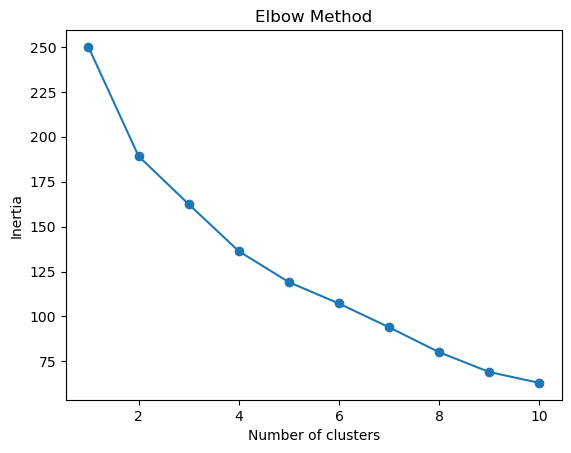

In [471]:
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=zid, n_init='auto')
    kmeans.fit(basic_features_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows wi

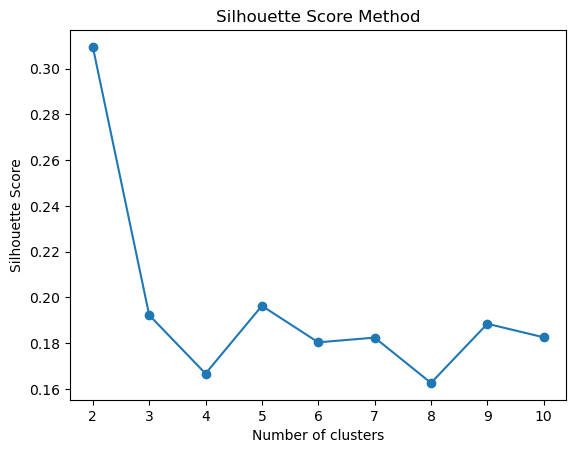

In [472]:
silhouette_scores = []
for i in range(2, 11): 
    kmeans = KMeans(n_clusters=i, random_state=zid, n_init='auto')
    kmeans.fit(basic_features_scaled)
    score = silhouette_score(basic_features_scaled, kmeans.labels_)
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score Method')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [473]:
kmeans = KMeans(n_clusters=4, random_state=zid).fit(basic_features_scaled)

df['rf_cluster'] = kmeans.labels_
df['rf_cluster']

C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


0     3
1     3
2     0
3     3
4     2
5     0
6     3
7     0
8     0
9     2
10    3
11    0
12    2
13    0
14    0
15    0
16    3
17    0
18    1
19    0
20    1
21    2
22    0
23    0
24    0
25    2
26    2
27    0
28    0
29    1
30    1
31    0
32    0
33    0
34    0
35    0
36    0
37    0
38    1
39    0
40    2
41    1
42    1
43    1
44    2
45    0
46    0
47    0
48    0
49    0
Name: rf_cluster, dtype: int32

In [474]:
pd.crosstab(df['rf_cluster'], df['label'])

label,MFW,noMFW
rf_cluster,,
0,16,12
1,1,7
2,4,4
3,4,2


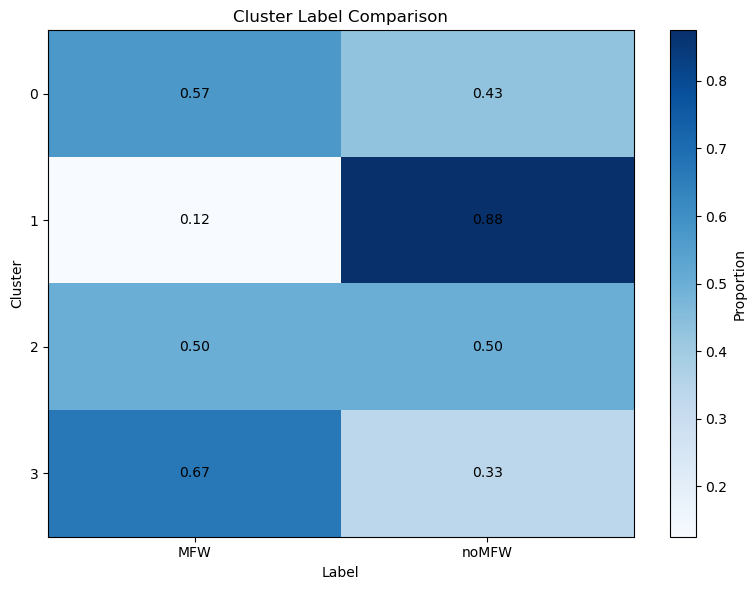

In [475]:
label_cluster_table = pd.crosstab(df['rf_cluster'], df['label'])
label_cluster_table_normalized = label_cluster_table.div(label_cluster_table.sum(axis=1), axis=0)

plt.figure(figsize=(8, 6))
plt.imshow(label_cluster_table_normalized, cmap="Blues", aspect="auto")

plt.colorbar(label="Proportion")
plt.xticks(ticks=np.arange(label_cluster_table.columns.size), labels=label_cluster_table.columns, rotation=0)
plt.yticks(ticks=np.arange(label_cluster_table.index.size), labels=label_cluster_table.index)
plt.title("Cluster Label Comparison")
plt.xlabel("Label")
plt.ylabel("Cluster")

for i in range(label_cluster_table_normalized.shape[0]):
    for j in range(label_cluster_table_normalized.shape[1]):
        plt.text(j, i, f"{label_cluster_table_normalized.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

In [476]:
rf_feature_list_extended = var_counts[0:15].index.tolist()
rf_feature_list_extended

['shearing_deformation_925',
 'ivt',
 'total_deformation_850',
 't_grad_850',
 'tadv_925',
 'pv_850',
 'fgen_925',
 't_850',
 'pv_700',
 'pv_300',
 'pv_925',
 'total_deformation_925',
 'pv_1000',
 'tadv_500',
 'wnd_300']

In [477]:
rf_features_extended = df[rf_feature_list_extended]
rf_features_extended.head()

,shearing_deformation_925,ivt,total_deformation_850,t_grad_850,tadv_925,pv_850,fgen_925,t_850,pv_700,pv_300,pv_925,total_deformation_925,pv_1000,tadv_500,wnd_300
0,8.407477,291.600715,11.911438,5.513050,1.566658,1.192982e-12,4.690558,277.23926,5.168937e-13,1.615085e-12,8.204532e-13,14.608564,3.146415e-13,1.113005,66.406730
1,12.990286,75.031038,18.081631,3.667785,-0.084205,7.191460e-13,3.606967,280.56128,6.330504e-13,2.824925e-12,2.770781e-13,15.440324,1.959496e-13,0.686703,62.199850
2,-13.388763,856.715163,6.541543,1.439914,0.178068,7.535887e-13,-0.549071,281.40173,5.650719e-13,-3.753535e-14,1.251950e-12,17.926046,1.095274e-13,0.377091,46.878395
3,6.175706,583.936731,12.933026,3.458344,1.514117,2.183340e-12,0.435262,278.13910,8.542314e-13,1.088309e-13,1.469326e-12,15.198784,4.105159e-13,3.009239,62.548008
4,-5.177271,445.809665,3.635283,0.839231,-1.305664,8.091834e-13,-2.152683,281.07303,5.557943e-13,3.312839e-13,2.026526e-12,13.298121,7.450257e-13,1.167569,43.977250


In [478]:
scaler_extended = StandardScaler()
rf_features_extended_scaled = scaler_extended.fit_transform(rf_features_extended)

In [479]:
kmeans = KMeans(n_clusters=4, random_state=zid).fit(rf_features_extended_scaled)

df['rf_cluster_extended'] = kmeans.labels_
df['rf_cluster_extended']

C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


0     0
1     0
2     0
3     0
4     0
5     0
6     2
7     0
8     0
9     3
10    0
11    3
12    3
13    3
14    3
15    0
16    2
17    3
18    0
19    3
20    0
21    3
22    0
23    0
24    0
25    0
26    0
27    3
28    0
29    2
30    2
31    0
32    3
33    0
34    0
35    0
36    0
37    3
38    2
39    0
40    0
41    0
42    1
43    2
44    3
45    0
46    0
47    3
48    3
49    3
Name: rf_cluster_extended, dtype: int32

In [480]:
pd.crosstab(df['rf_cluster_extended'], df['label'])

label,MFW,noMFW
rf_cluster_extended,,
0,17,11
1,0,1
2,2,4
3,6,9


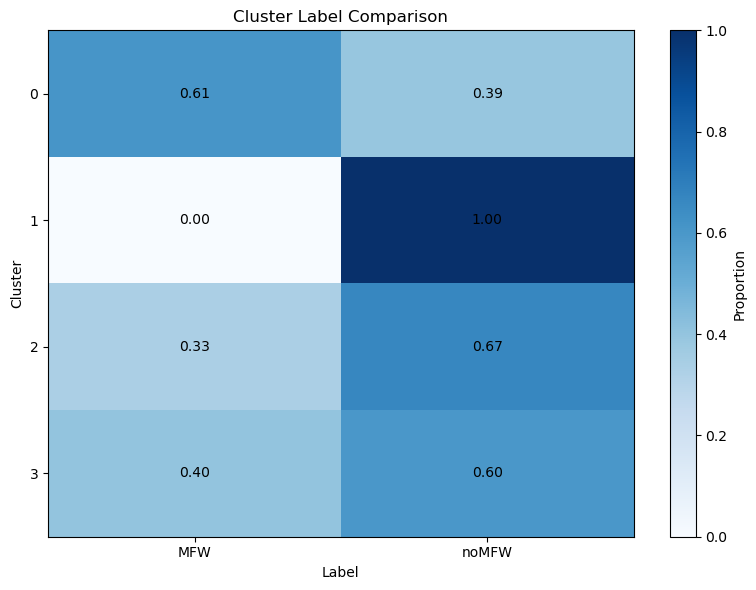

In [481]:
label_cluster_table = pd.crosstab(df['rf_cluster_extended'], df['label'])
label_cluster_table_normalized = label_cluster_table.div(label_cluster_table.sum(axis=1), axis=0)

plt.figure(figsize=(8, 6))
plt.imshow(label_cluster_table_normalized, cmap="Blues", aspect="auto")

plt.colorbar(label="Proportion")
plt.xticks(ticks=np.arange(label_cluster_table.columns.size), labels=label_cluster_table.columns, rotation=0)
plt.yticks(ticks=np.arange(label_cluster_table.index.size), labels=label_cluster_table.index)
plt.title("Cluster Label Comparison")
plt.xlabel("Label")
plt.ylabel("Cluster")

for i in range(label_cluster_table_normalized.shape[0]):
    for j in range(label_cluster_table_normalized.shape[1]):
        plt.text(j, i, f"{label_cluster_table_normalized.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

In [482]:
feature_cols

['pv_300',
 'pv_700',
 'pv_850',
 'pv_925',
 'pv_1000',
 'wnd_300',
 'wnd_500',
 'wnd_850',
 'z_250',
 'z_500',
 'z_850',
 'z_925',
 'z_1000',
 't_250',
 't_500',
 't_850',
 't_925',
 't_1000',
 'q_850',
 'q_925',
 'q_1000',
 'ivt',
 'ivt_grad',
 'thickness_1000_500',
 'qvec_div',
 'qvec_magn',
 'abs_vort',
 'thetae_850',
 'thetae_925',
 'thetae_1000',
 'fgen_700',
 'fgen_850',
 'fgen_925',
 'fgen_1000',
 'tadv_500',
 'tadv_850',
 'tadv_925',
 'tadv_1000',
 'rel_vort_500',
 'rel_vort_850',
 'rel_vort_925',
 'rel_vort_1000',
 'total_deformation_500',
 'total_deformation_850',
 'total_deformation_925',
 'total_deformation_1000',
 'shearing_deformation_500',
 'shearing_deformation_850',
 'shearing_deformation_925',
 'shearing_deformation_1000',
 'stretching_deformation_500',
 'stretching_deformation_850',
 'stretching_deformation_925',
 'stretching_deformation_1000',
 'thetae_grad_850',
 'thetae_grad_925',
 'thetae_grad_1000',
 't_grad_850',
 't_grad_925',
 't_grad_1000',
 'vort_def',
 'l

In [483]:
mi = mutual_info_classif(rf_features_extended_scaled, df['label'], discrete_features=False)
mi_series = pd.Series(mi, index=rf_feature_list_extended).sort_values(ascending=False)

top_features = mi_series.head(15).index.tolist()
top_features_selected = rf_features_extended_scaled[:, [rf_feature_list_extended.index(f) for f in top_features]]

kmeans = KMeans(n_clusters=4, random_state=zid).fit(top_features_selected)

df['cluster_extended'] = kmeans.labels_
df['cluster_extended']

C:\Users\Tony\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


0     0
1     0
2     0
3     0
4     0
5     0
6     2
7     0
8     0
9     3
10    0
11    3
12    3
13    3
14    3
15    0
16    2
17    3
18    0
19    3
20    0
21    3
22    0
23    0
24    0
25    0
26    0
27    3
28    0
29    2
30    2
31    0
32    3
33    0
34    0
35    0
36    0
37    3
38    2
39    0
40    0
41    0
42    1
43    2
44    3
45    0
46    0
47    3
48    3
49    3
Name: cluster_extended, dtype: int32

In [484]:
global_mean = pd.DataFrame(top_features_selected, columns=top_features).mean()
cluster_profiles = pd.DataFrame(top_features_selected, columns=top_features).groupby(df['cluster_selected']).mean()
cluster_diffs = cluster_profiles - global_mean

cluster_diffs

,shearing_deformation_925,tadv_925,wnd_300,total_deformation_925,fgen_925,pv_850,pv_700,tadv_500,pv_300,ivt,total_deformation_850,t_grad_850,t_850,pv_925,pv_1000
cluster_selected,,,,,,,,,,,,,,,
0,-0.349993,0.208850,-0.683883,-0.342700,-0.280891,-0.292866,-0.140271,-0.207111,-0.120993,-0.333928,-0.414943,-0.286632,-0.036622,-0.180511,-0.278005
1,0.383816,-0.538180,0.653869,0.061087,-0.132234,-0.226536,0.244097,0.237521,0.449950,0.052414,0.436509,0.209784,-0.279433,-0.329196,0.307616
2,2.723655,-1.497411,0.083054,2.578873,2.932860,1.939074,1.163205,-0.159628,-0.048579,0.693320,2.061172,0.721208,0.179225,1.290465,-0.025372
3,-0.455061,0.574490,0.524664,-0.082612,-0.074995,0.297567,-0.298076,0.162297,-0.253481,0.382090,-0.227449,0.117925,0.325052,0.364950,0.182768


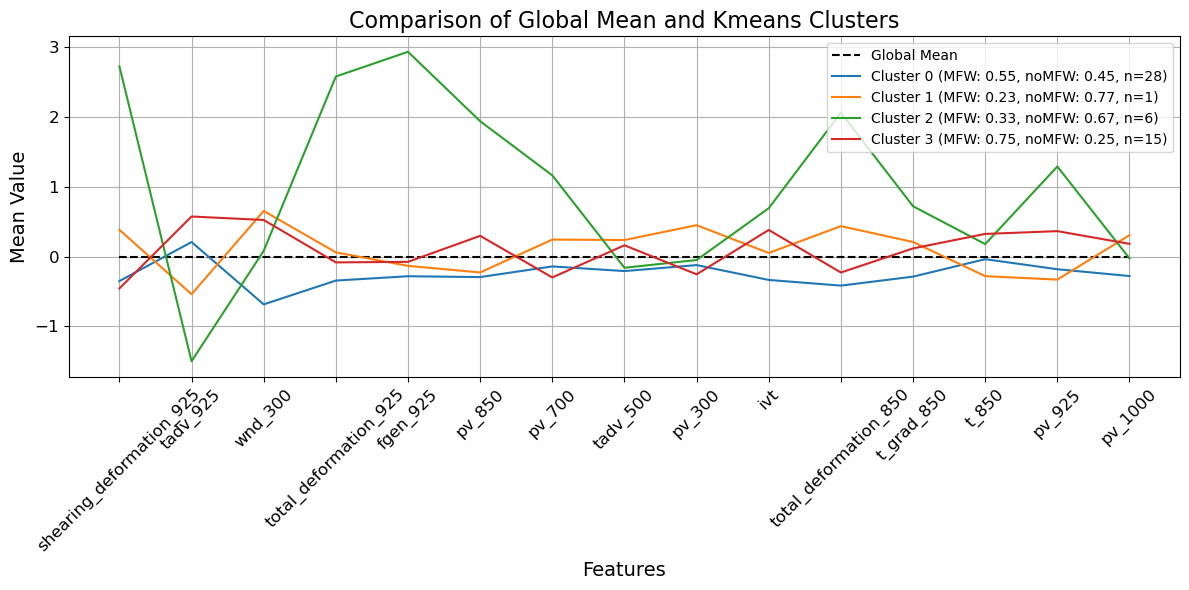

In [486]:
cluster_sizes = df['cluster_extended'].value_counts()

selected_features = cluster_profiles.columns.tolist()
plt.figure(figsize=(12, 6))

global_mean.plot(label='Global Mean', linestyle='--', color='black')

for cluster in range(len(cluster_profiles)): 
    cluster_label = f"Cluster {cluster} ({proportions[cluster]}, n={cluster_sizes[cluster]})"
    cluster_profiles.loc[cluster].plot(label=cluster_label)

plt.title('Comparison of Global Mean and Kmeans Clusters', fontsize=16)
plt.xlabel('Features', fontsize=14)
plt.ylabel('Mean Value', fontsize=14)
plt.xticks(ticks=range(len(selected_features)), labels=selected_features, rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()